# **1. Perkenalan Dataset**


**Business Understanding**

1. memahami perilaku customer,
2. mengidentifikasi customer loyal,
3. menemukan high spender,
4. mengetahui inactive customer.

# **2. Import Library**

In [1]:
#Type your code here
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# **3. Data Wrangling**

## Read data

In [2]:
# # Upload data
# from google.colab import files
# uploaded = files.upload()

In [3]:
# Baca data
df = pd.read_csv('Data_hasil_clustering_kmeans.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,0


## Data asessing

In [4]:
# cek info data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  int64  
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  int64  
 7   Country      392692 non-null  object 
 8   TotalPrice   392692 non-null  float64
 9   Month        392692 non-null  object 
 10  cluster      392692 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 33.0+ MB


In [5]:
# cek missing value
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalPrice,0
Month,0


In [6]:
# cek duplicated data
df.duplicated().sum()


np.int64(0)

# **4. Exploratory Data Analysis (EDA)**


In [7]:
# Copy data
df_clean = df.copy()
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,0


/tmp/ipykernel_15742/3393536614.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


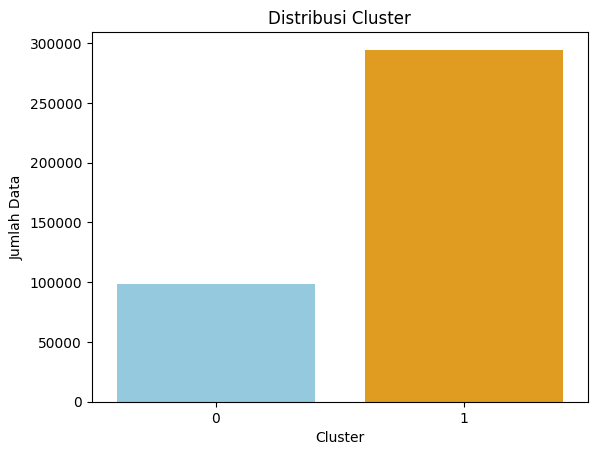

In [8]:
# visualisasi Distribusi kelas Label

# Warna custom
colors = ['skyblue', 'orange']

# Countplot
sns.countplot(
    x='cluster',
    data=df_clean,
    palette=colors
)

plt.title('Distribusi Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')

plt.show()

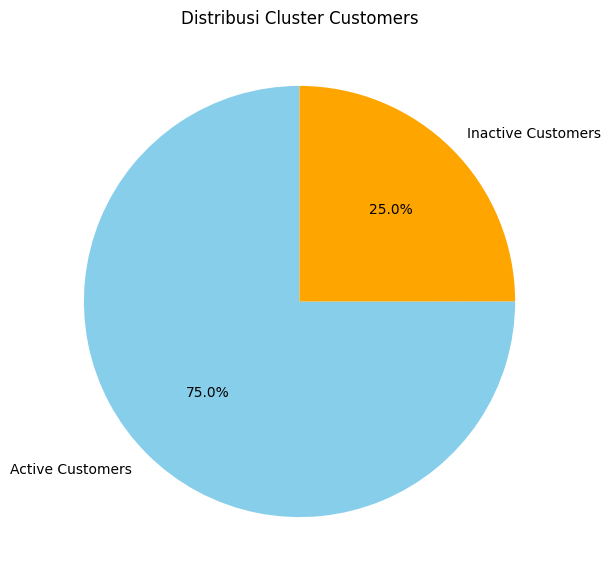

In [9]:
# Visualisasi Distribusi Cluster (Pie Chart)

import matplotlib.pyplot as plt

# Nama cluster
cluster_names = {
    0: 'Inactive Customers',
    1: 'Active Customers'
}

# Mengubah label cluster menjadi nama
cluster_counts = df_clean['cluster'].map(cluster_names).value_counts()

# Warna custom
colors = ['skyblue', 'orange']

# Pie chart
plt.figure(figsize=(7,7))

plt.pie(
    cluster_counts,
    labels=cluster_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Distribusi Cluster Customers')

plt.show()

/tmp/ipykernel_15742/4156201998.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


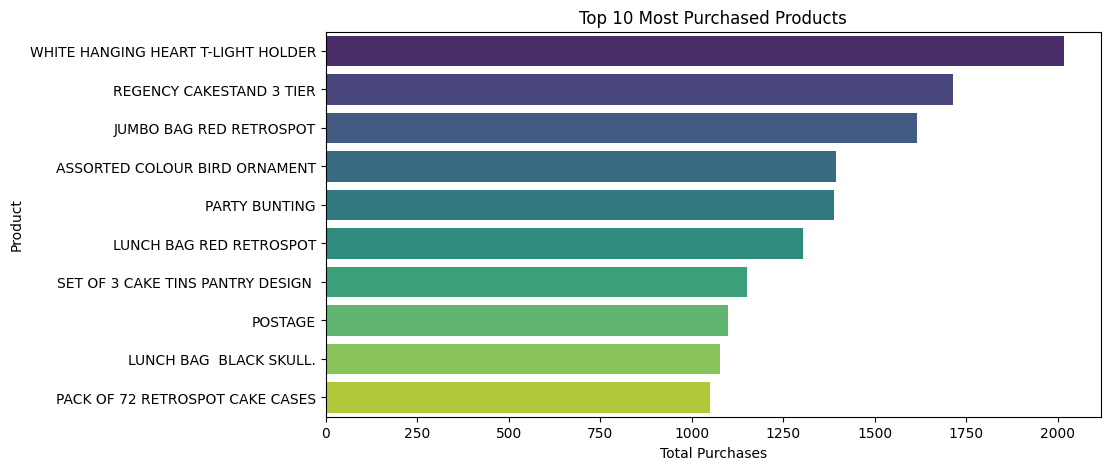

In [10]:
# Produk paling sering dibeli
# Top 10 product
top_product = df_clean['Description'].value_counts().head(10)

# Visualisasi
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_product.values,
    y=top_product.index,
    palette='viridis'
)

plt.title('Top 10 Most Purchased Products')
plt.xlabel('Total Purchases')
plt.ylabel('Product')
plt.show()

/tmp/ipykernel_15742/469980451.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


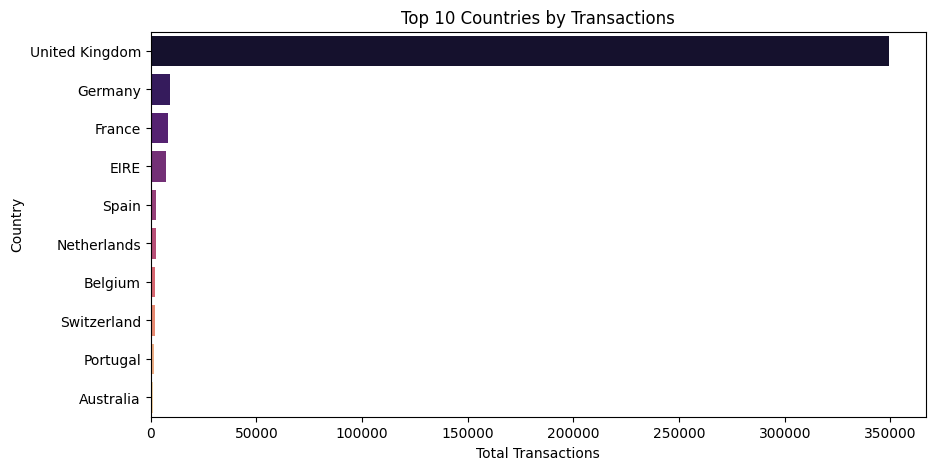

In [11]:
# Top Country Negara dengan transaksi terbanyak
# Top country
top_country = df_clean['Country'].value_counts().head(10)

# Visualisasi
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_country.values,
    y=top_country.index,
    palette='magma'
)

plt.title('Top 10 Countries by Transactions')
plt.xlabel('Total Transactions')
plt.ylabel('Country')
plt.show()

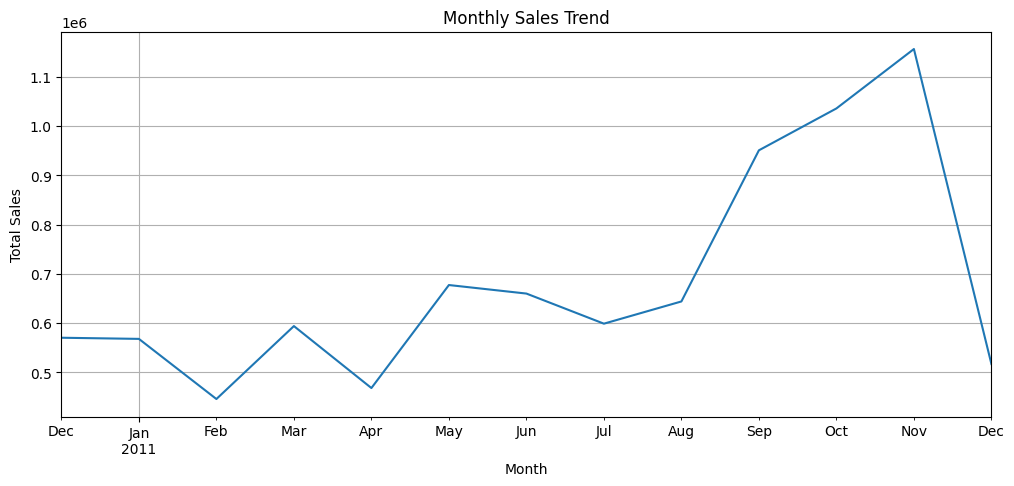

In [12]:
# Tren penjualan per bulan
# Konversi InvoiceDate ke datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Membuat kolom total sales
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Membuat kolom bulan
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')

# Monthly sales
monthly_sales = df_clean.groupby('Month')['TotalPrice'].sum()

# Visualisasi
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

/tmp/ipykernel_15742/3927575546.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


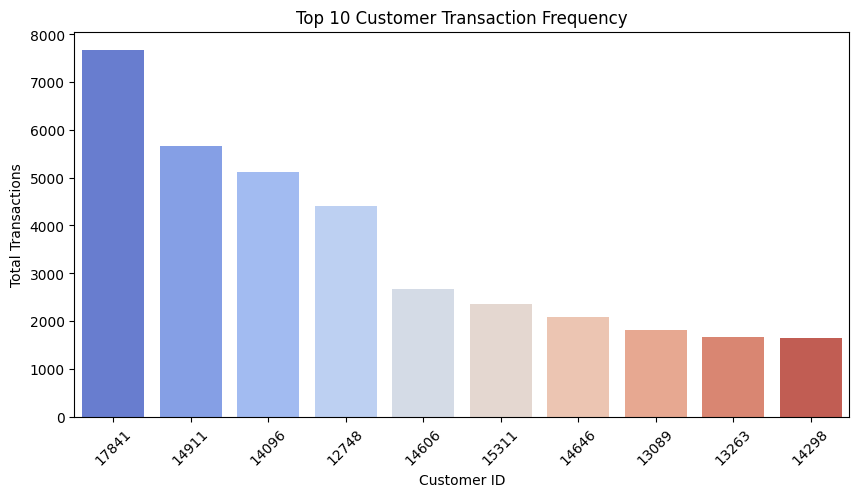

In [13]:
# Customer dengan transaksi terbanyak
# Frekuensi customer
customer_freq = df_clean['CustomerID'].value_counts().head(10)

# Visualisasi
plt.figure(figsize=(10,5))

sns.barplot(
    x=customer_freq.index.astype(str),
    y=customer_freq.values,
    palette='coolwarm'
)

plt.title('Top 10 Customer Transaction Frequency')
plt.xlabel('Customer ID')
plt.ylabel('Total Transactions')
plt.xticks(rotation=45)
plt.show()

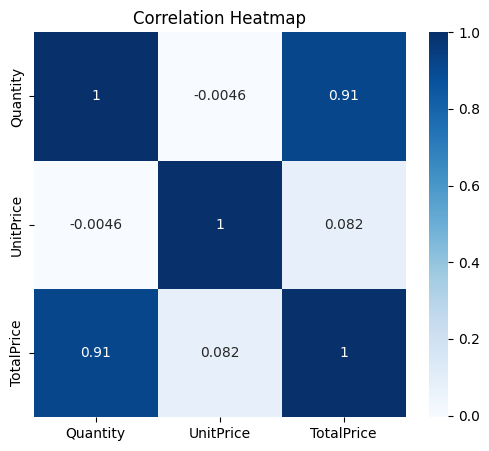

In [14]:
# Heatmap Korelasi
# Korelasi numerik
corr = df_clean[
    [
        'Quantity',
        'UnitPrice',
        'TotalPrice'
    ]
].corr()

# Visualisasi heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Heatmap')
plt.show()

# **5. Data Preprocessing**

In [15]:
df_class = df_clean.copy()
df_class.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,0


In [16]:
# Drop Kolom Tidak Penting
df_class = df_class.drop(
    columns=[
        'Description',
        'InvoiceNo'
    ]
)

In [17]:
# Konversi Datetime
df_class['InvoiceDate'] = pd.to_datetime(
    df_class['InvoiceDate']
)

df_class['Year'] = df_class['InvoiceDate'].dt.year
df_class['Month_Num'] = df_class['InvoiceDate'].dt.month
df_class['Day'] = df_class['InvoiceDate'].dt.day
df_class['Hour'] = df_class['InvoiceDate'].dt.hour

df_class = df_class.drop(columns=['InvoiceDate'])

In [18]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'StockCode',
    'Country',
    'Month'
]

for col in categorical_cols:
    df_class[col] = le.fit_transform(df_class[col])

In [19]:
df_class.head()

,StockCode,Quantity,UnitPrice,CustomerID,Country,TotalPrice,Month,cluster,Year,Month_Num,Day,Hour
0,3233,6,2.55,17850,35,15.30,0,0,2010,12,1,8
1,2643,6,3.39,17850,35,20.34,0,0,2010,12,1,8
2,2847,8,2.75,17850,35,22.00,0,0,2010,12,1,8
3,2795,6,3.39,17850,35,20.34,0,0,2010,12,1,8
4,2794,6,3.39,17850,35,20.34,0,0,2010,12,1,8


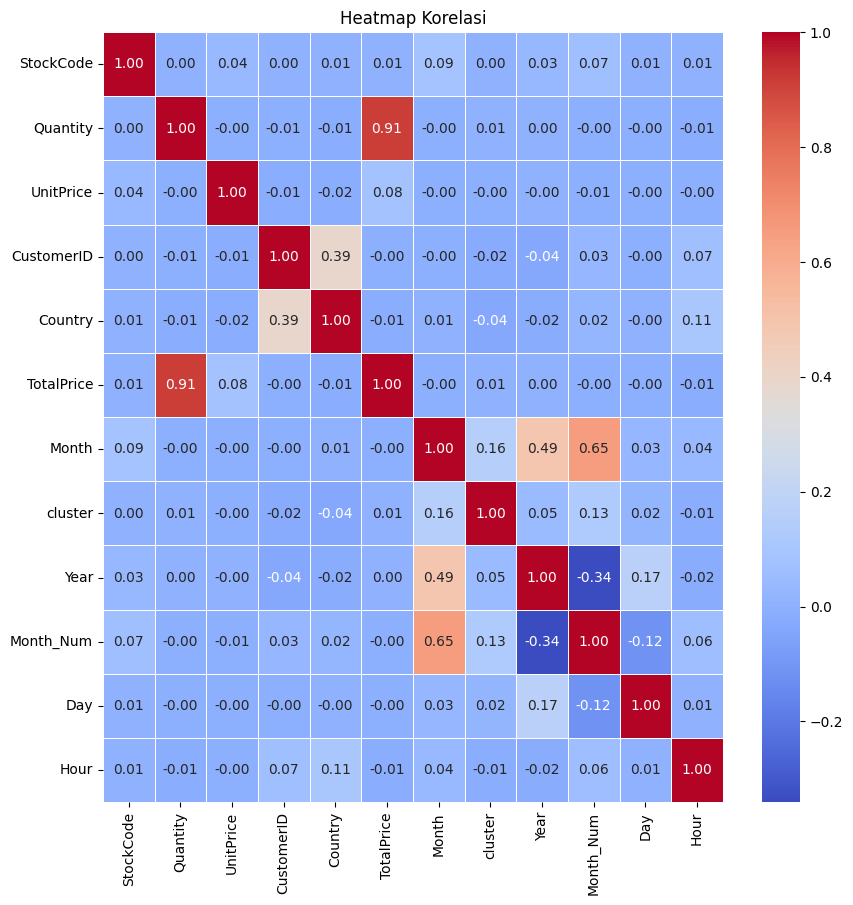

In [20]:
# plot matrik korelasi
num_features = df_class.select_dtypes(include=[np.number])
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(10, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

## Tangani outlier

In [21]:
# cek outlier

numeric_columns = df_class.select_dtypes(include=['number']).columns

outlier_summary = []

for col in numeric_columns:
    Q1 = df_class[col].quantile(0.25)
    Q3 = df_class[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_class[(df_class[col] < lower_bound) | (df_class[col] > upper_bound)]

    outlier_summary.append({
        'Feature': col,
        'Jumlah Outlier': len(outliers),
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

       Feature  Jumlah Outlier  Lower Bound  Upper Bound
0    StockCode               0     -823.000     3857.000
1     Quantity           25616      -13.000       27.000
2    UnitPrice           34112       -2.500        7.500
3   CustomerID               0     9701.000    21045.000
4      Country           43489       35.000       35.000
5   TotalPrice           31231      -17.325       42.075
6        Month               0       -5.000       19.000
7      cluster           98135        1.000        1.000
8         Year           25670     2011.000     2011.000
9    Month_Num               0       -4.000       20.000
10         Day               0      -15.500       44.500
11        Hour            4012        6.500       18.500


In [22]:
# handling outlier menggunakan log transformation.
import numpy as np

df_class['Quantity'] = np.log1p(df_class['Quantity'])
df_class['UnitPrice'] = np.log1p(df_class['UnitPrice'])
df_class['TotalPrice'] = np.log1p(df_class['TotalPrice'])

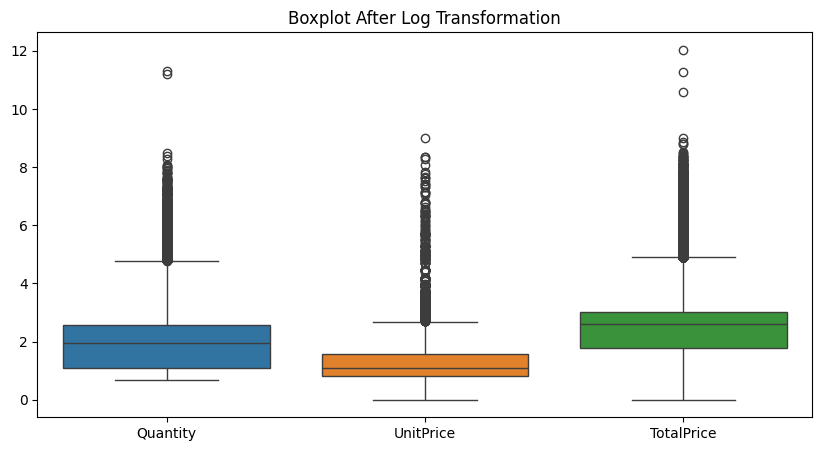

In [23]:
# Cek ulang boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.boxplot(data=df_class[
    ['Quantity', 'UnitPrice', 'TotalPrice']
])

plt.title('Boxplot After Log Transformation')

plt.show()

## Data normalisasi

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_cols = [
    'Quantity',
    'UnitPrice',
    'TotalPrice'
]

df_class[numeric_cols] = scaler.fit_transform(
    df_class[numeric_cols]
)

# **6. Data Splitting**

In [25]:
from sklearn.model_selection import train_test_split

# Feature dan target
X = df_class.drop('cluster', axis=1)
y = df_class['cluster']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Cek ukuran data
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (314153, 11)
X_test  : (78539, 11)
y_train : (314153,)
y_test  : (78539,)


# **7. Membangun Model Klasifikasi**


## Decesion Tree

In [29]:
# Model Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model Decision Tree
model = DecisionTreeClassifier(
    random_state=42
)

# Training
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9888335731292733

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     19627
           1       0.99      0.99      0.99     58912

    accuracy                           0.99     78539
   macro avg       0.99      0.99      0.99     78539
weighted avg       0.99      0.99      0.99     78539



## Random Forest

In [30]:
# Model Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9750697105896433

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.91      0.95     19627
           1       0.97      1.00      0.98     58912

    accuracy                           0.98     78539
   macro avg       0.98      0.95      0.97     78539
weighted avg       0.98      0.98      0.97     78539

